# AI ReturnShield — Phase 3: Model Explainability & Merchant Risk Insights

**Project:** AI ReturnShield (Razorpay Buildathon - Track 02: AI Risk Manager)  
**Objective:** Integrate SHAP-based model explainability to translate complex machine learning predictions into actionable, human-readable risk summaries for online merchants.

---

### Notebook Overview
1. **Model & Data Loading**: Load the saved XGBoost pipeline (`models/returnshield_pipeline.joblib`) and validation set.
2. **Global Feature Importance**: Quantify and plot overall model drivers using SHAP (SHapley Additive exPlanations).
3. **SHAP Summary Plot**: Visualize the magnitude and directional impact of features across all validation cases.
4. **Local Merchant Explanations**: Generate individual risk reports for **5 diverse return requests** spanning LOW, MEDIUM, and HIGH risk levels.
5. **Human-Readable Translation**: Convert technical SHAP attributions into clear business terms (e.g. order value spikes, account recency, chargeback history, protective factors).
6. **Disclaimer & Governance**: Highlight that model outputs serve as risk indicators for merchant review, not definitive legal proof of fraud.


In [1]:
# Imports
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import shap

# Ensure src module can be imported
sys.path.append(os.path.abspath(os.path.join("..")))
sys.path.append(os.path.abspath(os.path.join(".")))

from sklearn.model_selection import train_test_split
from src.evaluation.explainability import ReturnShieldExplainer

# Visualization styling
sns.set_theme(style="whitegrid")
plt.rcParams["font.sans-serif"] = "DejaVu Sans"
plt.rcParams["font.size"] = 10
%matplotlib inline

print("Exploration libraries and ReturnShieldExplainer imported successfully!")


Exploration libraries and ReturnShieldExplainer imported successfully!


## Step 1: Load Model Pipeline & Validation Data

We load the trained XGBoost model pipeline from `models/returnshield_pipeline.joblib` and reconstruct the exact 15% validation dataset from `data/raw/return_requests.csv`.


In [2]:
# 1. Load Data
data_path = os.path.join("..", "data", "raw", "return_requests.csv")
if not os.path.exists(data_path):
    data_path = os.path.join("data", "raw", "return_requests.csv")

df = pd.read_csv(data_path)

TARGET = "is_suspicious"
X = df.drop(columns=["customer_id", "order_id", TARGET])
y = df[TARGET]

# Exact 70/15/15 split
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.15, stratify=y, random_state=42
)
val_size_ratio = 15.0 / 85.0
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=val_size_ratio, stratify=y_train_val, random_state=42
)
df_val = df.iloc[X_val.index].copy()

# 2. Load Pipeline & Initialize Explainer
model_path = os.path.join("..", "models", "returnshield_pipeline.joblib")
if not os.path.exists(model_path):
    model_path = os.path.join("models", "returnshield_pipeline.joblib")

explainer = ReturnShieldExplainer(model_path)
print(f"Validation dataset loaded ({len(df_val)} rows). Explainer initialized.")


Validation dataset loaded (1500 rows). Explainer initialized.


## Step 2: Global Feature Importance with SHAP

Global feature importance measures the average magnitude of feature contributions across the validation set. Unlike standard Gini impurity importances, SHAP values guarantee consistency and fair attribution.


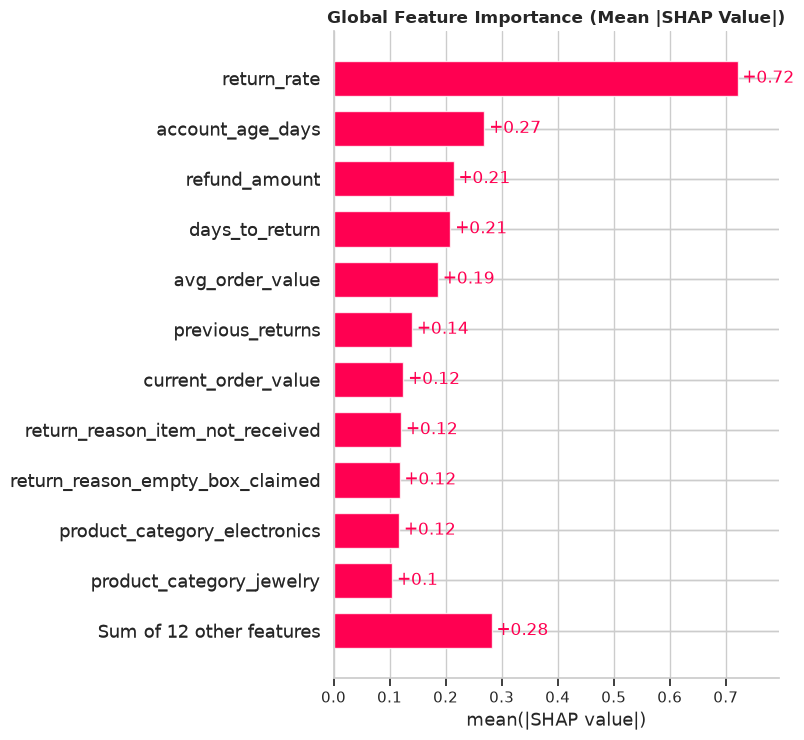

In [3]:
# Calculate SHAP values for validation set
shap_vals, X_trans = explainer.get_shap_values(df_val)

# Plot Global Feature Importance (Bar Chart)
fig, ax = plt.subplots(figsize=(10, 6))
shap.plots.bar(shap_vals, max_display=12, show=False)
plt.title("Global Feature Importance (Mean |SHAP Value|)", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()


## Step 3: SHAP Summary Plot (Beeswarm)

The SHAP summary plot illustrates both feature importance and the directional effect of feature values:
- **Red dots**: High feature value
- **Blue dots**: Low feature value
- **Right side (+ SHAP)**: Pushes model prediction toward **Suspicious (1)**
- **Left side (- SHAP)**: Pushes model prediction toward **Normal (0)**


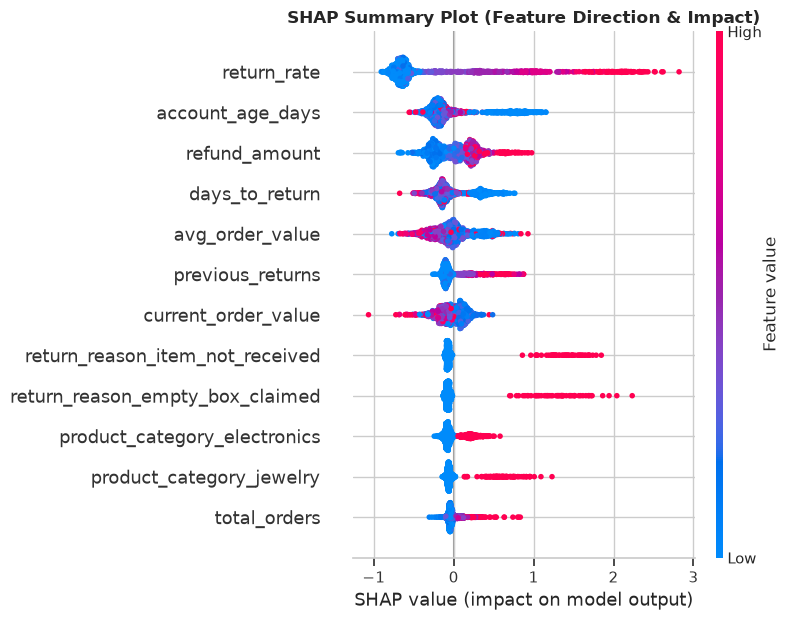

In [4]:
# SHAP Summary Beeswarm Plot
fig, ax = plt.subplots(figsize=(10, 7))
shap.summary_plot(shap_vals.values, X_trans, max_display=12, show=False)
plt.title("SHAP Summary Plot (Feature Direction & Impact)", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()


## Step 4: Merchant-Friendly Local Explanations for 5 Example Requests

We generate merchant risk reports for **5 distinct return requests** representing diverse customer profiles and risk levels (High Risk, Medium Risk, Low Risk).

Raw SHAP numbers are abstracted into clear, operational risk statements and protective factors for merchant decision-makers.


In [5]:
# Select 5 representative return request samples from validation set
# We select examples spanning low, medium, and high predicted risk scores
val_probs = explainer.pipeline.predict_proba(df_val)[:, 1]
df_val_with_probs = df_val.copy()
df_val_with_probs['predicted_prob'] = val_probs

high_risk_sample = df_val_with_probs[df_val_with_probs['predicted_prob'] >= 0.45].iloc[0]
high_risk_sample_2 = df_val_with_probs[df_val_with_probs['predicted_prob'] >= 0.35].iloc[1]
med_risk_sample = df_val_with_probs[(df_val_with_probs['predicted_prob'] >= 0.25) & (df_val_with_probs['predicted_prob'] < 0.35)].iloc[0]
low_risk_sample_1 = df_val_with_probs[df_val_with_probs['predicted_prob'] < 0.15].iloc[0]
low_risk_sample_2 = df_val_with_probs[df_val_with_probs['predicted_prob'] < 0.10].iloc[1]

sample_indices = [
    high_risk_sample.name,
    high_risk_sample_2.name,
    med_risk_sample.name,
    low_risk_sample_1.name,
    low_risk_sample_2.name
]

print("=== GENERATING 5 MERCHANT-FRIENDLY RETURN RISK REPORTS ===\n")

for i, idx in enumerate(sample_indices, 1):
    raw_row = df_val.loc[idx]
    exp = explainer.explain_request(raw_row, threshold=0.25)

    print("=" * 70)
    print(f"CASE {i}: Customer {exp['customer_id']} | Order {exp['order_id']}")
    print("=" * 70)
    print(f"  Risk Score : {exp['risk_score']:.4f} ({exp['risk_score']*100:.1f}%)")
    print(f"  Risk Level : [{exp['risk_level']}]")
    print("-" * 70)
    print("  TOP RISK FACTORS (Pushing score UP):")
    for factor in exp['top_risk_factors']:
        print(f"    • {factor}")
    print("-" * 70)
    print("  TOP PROTECTIVE FACTORS (Pushing score DOWN):")
    for factor in exp['top_protective_factors']:
        print(f"    • {factor}")
    print("-" * 70)
    print(f"  [Notice] {exp['disclaimer']}")
    print("=" * 70 + "\n")


=== GENERATING 5 MERCHANT-FRIENDLY RETURN RISK REPORTS ===

CASE 1: Customer CUST_03970 | Order ORD_03970
  Risk Score : 0.4562 (45.6%)
  Risk Level : [HIGH RISK]
----------------------------------------------------------------------
  TOP RISK FACTORS (Pushing score UP):
    • High historical return rate (36.8%)
    • Immediate return requested (1 days after delivery)
    • Prior refund history (5 refunds)
----------------------------------------------------------------------
  TOP PROTECTIVE FACTORS (Pushing score DOWN):
    • Order value ($150.58) consistent with typical spending ($98.38)
    • Zero previous chargebacks on file
    • Standard return reason ('Size Fit Issue')
----------------------------------------------------------------------
  [Notice] Explanations represent model-attributed risk indicators based on historical patterns, not definitive proof of customer fraud.

CASE 2: Customer CUST_05462 | Order ORD_05462
  Risk Score : 0.4470 (44.7%)
  Risk Level : [HIGH RISK]
-

## Step 5: Visualizing Local SHAP Explanation for an Individual Request

We plot the SHAP waterfall graph for a high-risk return request to demonstrate individual feature attribution for audit and review.


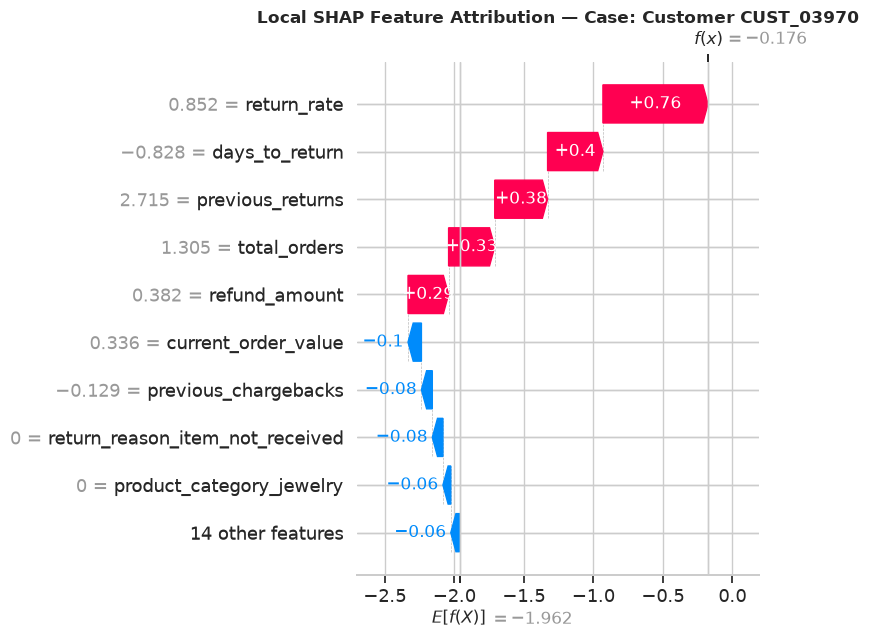

In [6]:
# Select the high-risk example row
sample_idx = high_risk_sample.name
single_df = df_val.loc[[sample_idx]]

single_shap_vals, single_X_trans = explainer.get_shap_values(single_df)

# Plot Waterfall plot for individual explanation
fig, ax = plt.subplots(figsize=(10, 6))
shap.plots.waterfall(single_shap_vals[0], max_display=10, show=False)
plt.title(f"Local SHAP Feature Attribution — Case: Customer {high_risk_sample['customer_id']}", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()


## Step 6: Summary & Governance Considerations

### Summary of Explainability Integration
1. **Global Transparency**: SHAP analysis identifies `return_rate`, `previous_chargebacks`, `current_order_value`, `account_age_days`, and specific return claim reasons (`empty_box_claimed`, `item_not_received`) as top drivers of risk scores.
2. **Merchant Usability**: Raw floating-point SHAP contributions are translated into intuitive, non-technical bullet points suitable for merchant dashboards and manual review queues.
3. **Responsible AI Governance**: Explanations serve strictly as risk indicators to assist merchant operations. They do not constitute legal proof of fraud.
